# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 11 — AutoML: AutoTS y MLForecast

**Objetivo de este notebook:** cubrir la categoría "AutoML" del punto 2 de la consigna del TP2, evitando las herramientas bloqueadas por incompatibilidad (PyCaret exige Python 3.9-3.11; H2O AutoML requiere una JVM/Java aparte — ver `docs/Observaciones_TP_Final_Modelos_Clase6_7.md`). **AutoTS** explora automáticamente una familia de modelos y las **MLForecast** ajusta varios regresores tabulares (incluyendo LightGBM) sobre variables rezagadas, ambas en Python puro y CPU.

**Dataset:** se usa `serie_california_tratada.csv` (salida de `07b_tratamiento_datos.ipynb`, ya sin huecos en el índice) — por eso ya no hace falta el reindex+interpolate manual que llevaba antes la sección de MLForecast.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from autots import AutoTS
from mlforecast import MLForecast
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california_tratada.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
datos.index = datos.index.tz_localize(None)

HORAS_TEST = 24 * 7
VENTANA_DIAS = 365
print(f"Filas: {len(datos):,} | Ventana: {VENTANA_DIAS} días | Holdout: {HORAS_TEST} horas")

Filas: 242,402 | Ventana: 365 días | Holdout: 168 horas


## 1. AutoTS

`model_list="superfast"` restringe la búsqueda a modelos livianos (suficiente para datos horarios con un patrón estacional claro); es normal que aparezcan mensajes `Template Eval Error` durante la búsqueda genética — son plantillas que AutoTS descarta automáticamente al no aplicar a estos datos, no errores del notebook.

In [2]:
resultados_autots = {}

for col in datos.columns:
    print(f"\n{'='*60}\n{col}\n{'='*60}")
    serie = datos[col].iloc[-(VENTANA_DIAS * 24):]
    train, test = serie.iloc[:-HORAS_TEST], serie.iloc[-HORAS_TEST:]
    df_train = pd.DataFrame({"datetime": train.index, "value": train.values})

    modelo = AutoTS(
        forecast_length=HORAS_TEST, frequency="h", prediction_interval=0.95,
        model_list="superfast", ensemble=None, max_generations=5,
        num_validations=2, no_negatives=(col != "temperatura_c"), n_jobs="auto", verbose=0,
    )
    modelo = modelo.fit(df_train, date_col="datetime", value_col="value", id_col=None)
    prediccion = modelo.predict()
    pred_valores = prediccion.forecast["value"].values

    mae = mean_absolute_error(test.values, pred_valores)
    rmse = mean_squared_error(test.values, pred_valores) ** 0.5
    resultados_autots[col] = {
        "MAE": mae, "RMSE": rmse, "mejor_modelo": str(modelo.best_model_name),
        "_test_real": test.values.tolist(), "_test_pred": pred_valores.tolist(),
    }
    print(f"[AutoTS - {col}] mejor modelo interno: {modelo.best_model_name} | MAE={mae:.5f}  RMSE={rmse:.5f}")


ozono_ppm


Template Eval Error: ValueError('Unknown Distance Metric: sokalmichener') in model 12 in generation 0: SectionalMotif


Template Eval Error: ValueError('maximum supported dimension for an ndarray is currently 64, found 8424') in model 17 in generation 0: BasicLinearModel


Template Eval Error: ValueError('Unknown Distance Metric: kulczynski1') in model 28 in generation 0: SectionalMotif


Template Eval Error: Exception('Transformer FIRFilter failed on inverse') in model 43 in generation 0: AverageValueNaive


...

Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 129 in generation 2: SeasonalityMotif


Template Eval Error: Exception('Transformer ReconciliationTransformer failed on inverse') in model 133 in generation 2: GLS


Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 172 in generation 3: SectionalMotif


Template Eval Error: Exception('Transformer PCA failed on fit') in model 182 in generation 4: GLS


[AutoTS - radiacion_ghi_wm2] mejor modelo interno: SeasonalityMotif | MAE=50.18289  RMSE=88.70955


## 2. MLForecast

MLForecast exige una serie sin huecos desde el inicio (no sólo en las columnas de rezagos derivadas); con `serie_california_tratada.csv` esto ya está resuelto en origen (ver `07b_tratamiento_datos.ipynb`), sin necesidad de reindexar/interpolar acá.

In [3]:
resultados_mlforecast = {}

for col in datos.columns:
    serie_regular = datos[col].iloc[-(VENTANA_DIAS * 24):]

    train, test = serie_regular.iloc[:-HORAS_TEST], serie_regular.iloc[-HORAS_TEST:]
    df_train = pd.DataFrame({"unique_id": col, "ds": train.index, "y": train.values})

    mlf = MLForecast(
        models={"LightGBM": LGBMRegressor(verbose=-1, random_state=123),
                "RandomForest": RandomForestRegressor(n_estimators=200, random_state=123, n_jobs=-1),
                "LinearRegression": LinearRegression()},
        freq="h", lags=[1, 2, 3, 24, 48],
        date_features=["hour", "dayofweek"],
    )
    mlf.fit(df_train)
    pronostico = mlf.predict(HORAS_TEST)

    metricas_col = {}
    for modelo_nombre in ["LightGBM", "RandomForest", "LinearRegression"]:
        pred = pronostico[modelo_nombre].values
        mae = mean_absolute_error(test.values, pred)
        rmse = mean_squared_error(test.values, pred) ** 0.5
        metricas_col[modelo_nombre] = {"MAE": mae, "RMSE": rmse, "_pred": pred.tolist()}

    mejor = min(metricas_col, key=lambda m: metricas_col[m]["MAE"])
    resultados_mlforecast[col] = {
        "mejor_modelo": mejor,
        **{k: {"MAE": v["MAE"], "RMSE": v["RMSE"]} for k, v in metricas_col.items()},
        "_test_real": test.values.tolist(), "_test_pred": metricas_col[mejor]["_pred"],
    }
    print(f"[MLForecast - {col}] mejor: {mejor}  MAE={metricas_col[mejor]['MAE']:.5f}  RMSE={metricas_col[mejor]['RMSE']:.5f}")

[MLForecast - ozono_ppm] mejor: LinearRegression  MAE=0.01097  RMSE=0.01493


[MLForecast - temperatura_c] mejor: LightGBM  MAE=1.98591  RMSE=2.47609


[MLForecast - radiacion_ghi_wm2] mejor: RandomForest  MAE=25.13090  RMSE=53.28872


## 3. Pronósticos graficados

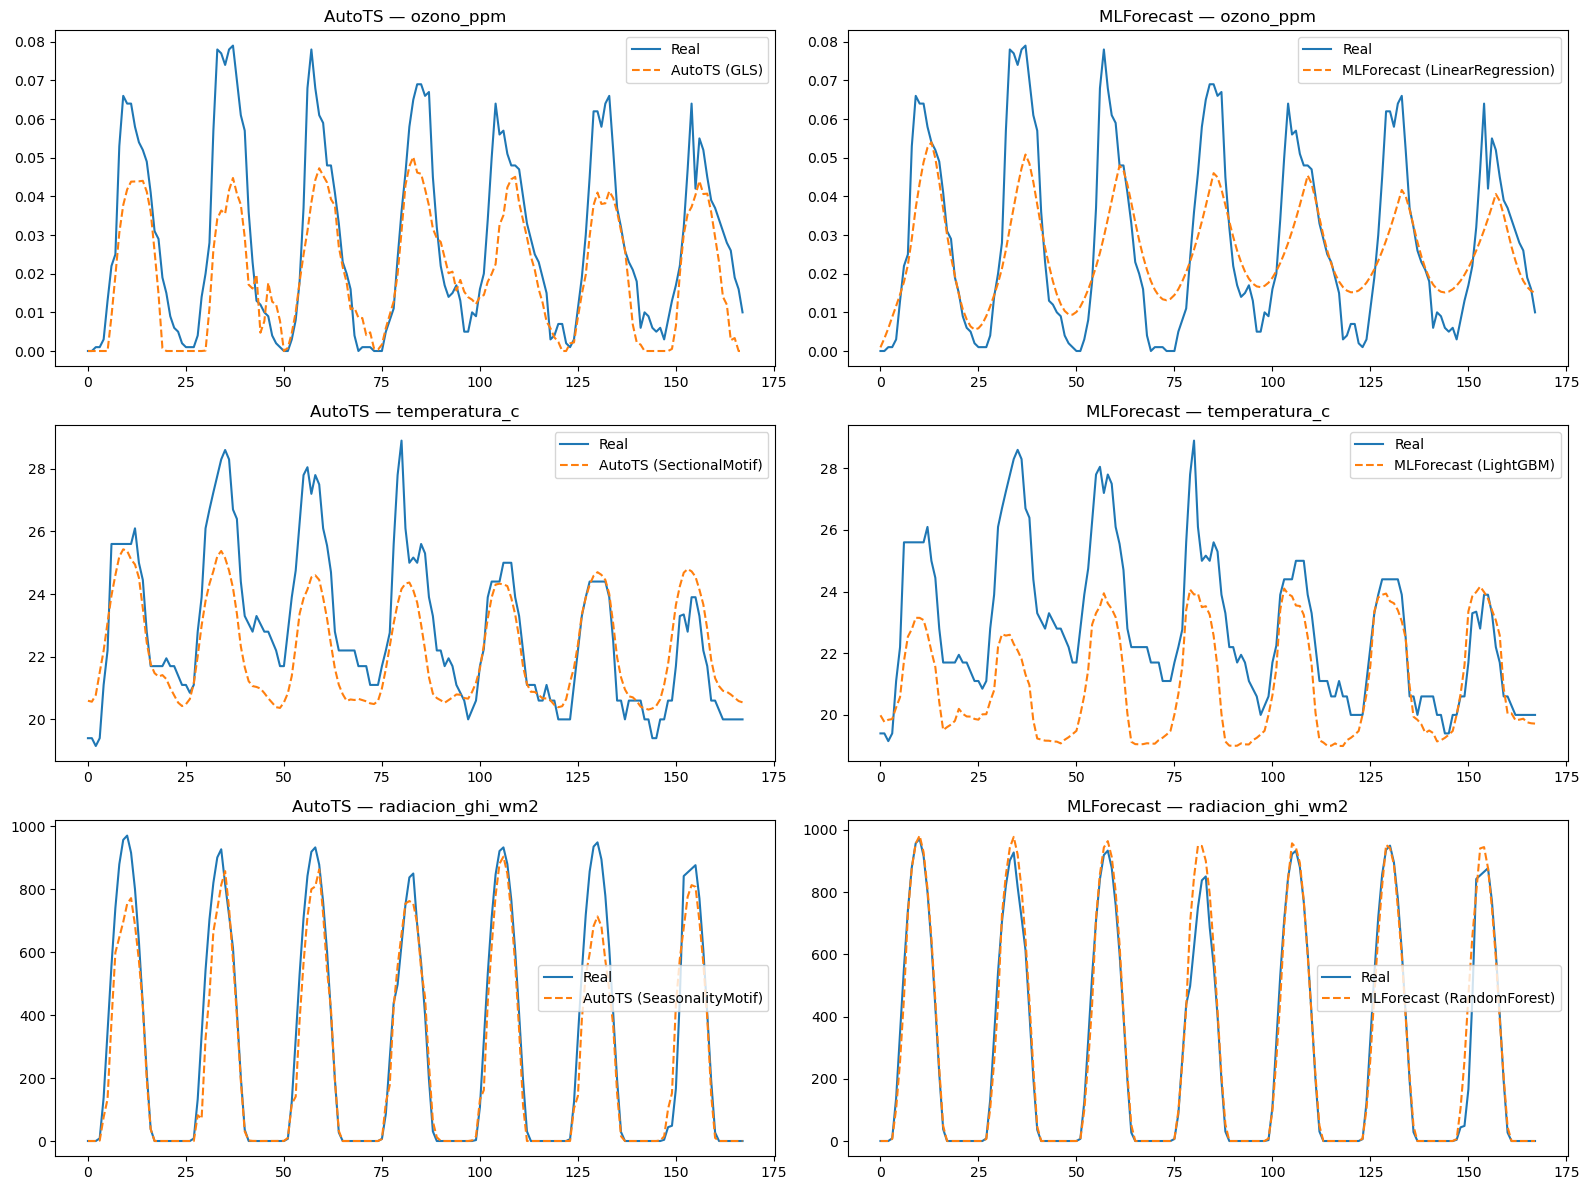

In [4]:
fig, axes = plt.subplots(len(datos.columns), 2, figsize=(16, 12))

for fila, col in enumerate(datos.columns):
    axes[fila, 0].plot(resultados_autots[col]["_test_real"], label="Real")
    axes[fila, 0].plot(resultados_autots[col]["_test_pred"], label=f"AutoTS ({resultados_autots[col]['mejor_modelo']})", linestyle="--")
    axes[fila, 0].set_title(f"AutoTS — {col}")
    axes[fila, 0].legend()

    axes[fila, 1].plot(resultados_mlforecast[col]["_test_real"], label="Real")
    axes[fila, 1].plot(resultados_mlforecast[col]["_test_pred"], label=f"MLForecast ({resultados_mlforecast[col]['mejor_modelo']})", linestyle="--")
    axes[fila, 1].set_title(f"MLForecast — {col}")
    axes[fila, 1].legend()

plt.tight_layout()
plt.show()

## 4. Guardado de resultados

In [5]:
def limpiar(resultados):
    return {col: {k: v for k, v in r.items() if not k.startswith("_")} for col, r in resultados.items()}

(PROJECT_ROOT / "data/processed/resultados_autots.json").write_text(
    json.dumps(limpiar(resultados_autots), indent=2), encoding="utf-8"
)
(PROJECT_ROOT / "data/processed/resultados_mlforecast.json").write_text(
    json.dumps(limpiar(resultados_mlforecast), indent=2), encoding="utf-8"
)

print("AutoTS:", json.dumps(limpiar(resultados_autots), indent=2))
print("\nMLForecast:", json.dumps(limpiar(resultados_mlforecast), indent=2))
print("\nProyecto listo para la comparación final entre todos los enfoques del TP2.")

AutoTS: {
  "ozono_ppm": {
    "MAE": 0.010690678329827548,
    "RMSE": 0.014634617890987016,
    "mejor_modelo": "GLS"
  },
  "temperatura_c": {
    "MAE": 1.1620961510262457,
    "RMSE": 1.5155182808004217,
    "mejor_modelo": "SectionalMotif"
  },
  "radiacion_ghi_wm2": {
    "MAE": 50.182886904761915,
    "RMSE": 88.70954644534612,
    "mejor_modelo": "SeasonalityMotif"
  }
}

MLForecast: {
  "ozono_ppm": {
    "mejor_modelo": "LinearRegression",
    "LightGBM": {
      "MAE": 0.011709525465279012,
      "RMSE": 0.014274080563400085
    },
    "RandomForest": {
      "MAE": 0.01106379301303854,
      "RMSE": 0.013290269697479005
    },
    "LinearRegression": {
      "MAE": 0.010972834918845879,
      "RMSE": 0.014932664679344308
    }
  },
  "temperatura_c": {
    "mejor_modelo": "LightGBM",
    "LightGBM": {
      "MAE": 1.9859110298207927,
      "RMSE": 2.4760863812604614
    },
    "RandomForest": {
      "MAE": 2.1424784722222086,
      "RMSE": 2.451100618593029
    },
    "Li